In [139]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import sage.all as sage
from sage.all import var, function, sin, cos, pi, ln, diff, e

In [140]:
xmin, xmax = -7, 7
ymin, ymax = -7, 7  

step = 0.01

num_sx = 20
num_sy = 5

# start_x, end_x = 0, 0
# start_y, end_y = ymin // 2, ymax // 2

start_x, end_x = xmin // 2, xmax // 2
start_y, end_y = -1.5, 1.5

compute_boundary = 7  # Stop computation when values exceed this

line_size = 0.75
scale = 'linear' # 'linear', 'semilogx', 'semilogy', 'loglog'

show_phase = True
vect_or_slope = 'vector' # 'neither', 'vector', 'slope'

In [141]:
# f : R x R -> R
# dx/dt = f(x, t)
def f(x, t):
    func = (x / t) - (t / x)
    return func
    # return (sage.real(func) ** 2 + sage.imag(func) ** 2) ** 0.5

In [142]:
base_size = 1

auto_aspect_ratio = False
aspect_ratio_const = 1

aspect_ratio = (ymax - ymin) / (xmax - xmin) if auto_aspect_ratio else aspect_ratio_const
figsize = (
    base_size * (xmax - xmin) / aspect_ratio,
    base_size * (ymax - ymin) / aspect_ratio,
)

In [143]:
ics = [
    [i, j]
    for i in np.linspace(start_x, end_x, num_sx)
    for j in np.linspace(start_y, end_y, num_sy)
]
# ics += [[0, 0]]

colors = cm.get_cmap("viridis")(np.linspace(0, 1, len(ics)))
ic_points = sum(
    [
        sage.point(
            [ics[i]],
            size=10,
            alpha=1,
            color=mcolors.to_hex(colors[i]),
            faceted=True,
            markeredgecolor="black",
        )
        for i in range(len(ics))
    ]
)

/var/folders/3j/5z92g6nn29n86z0mwbtybwc00000gn/T/ipykernel_70555/4080504957.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("viridis")(np.linspace(Integer(0), Integer(1), len(ics)))


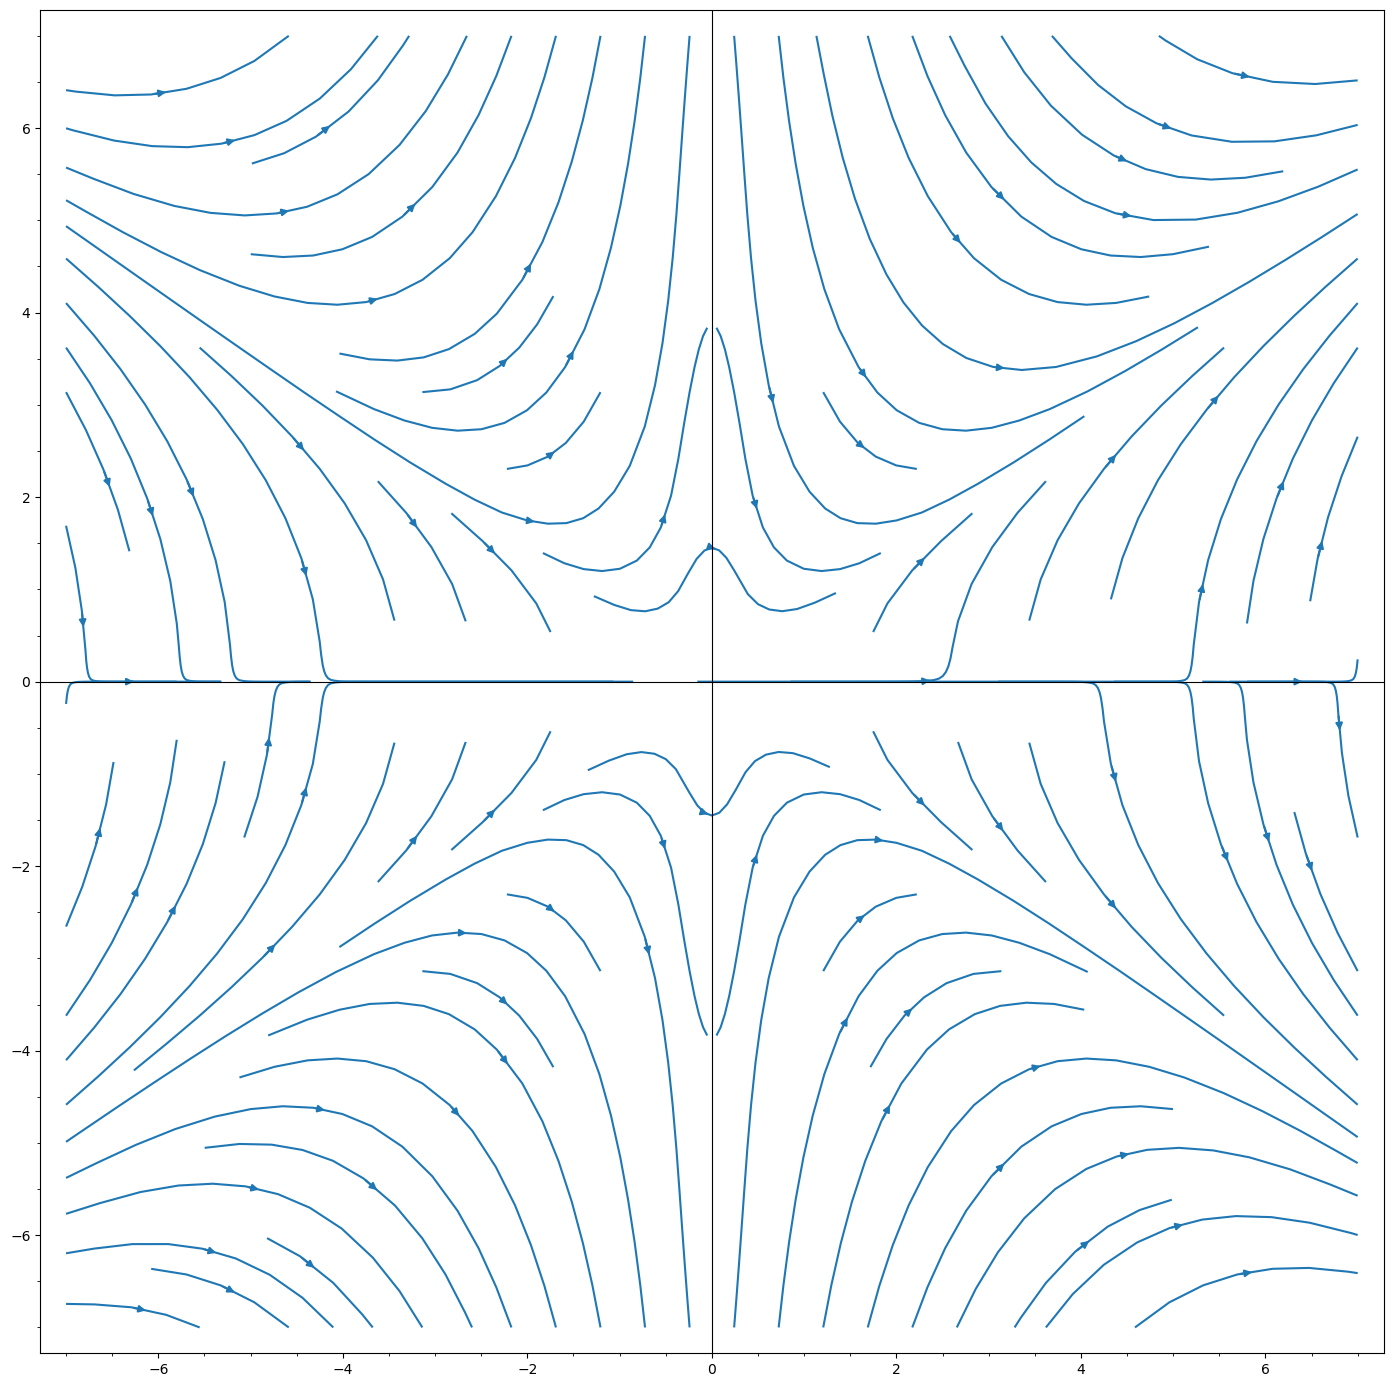

In [144]:
t, y = var("t y")
x = sage.function("x")(t)

if show_phase:
    phase_plot = sage.streamline_plot(
        f,
        (t, xmin, xmax),
        (y, ymin, ymax),
        figsize=figsize,
        scale=scale,
        aspect_ratio=aspect_ratio,
    )
    phase_plot.save("./Plots/2D/phase_plot.svg")
    sage.show(phase_plot)

In [145]:
def filter_solution(solution, compute_boundary=None):
    if compute_boundary is None:
        return solution
    filtered = []
    for point in solution:
        t_val, x_val = float(point[0]), float(point[1])
        if abs(t_val) > compute_boundary or abs(x_val) > compute_boundary:
            break
        filtered.append(point)
    return filtered


solutions = []
for idx, i in enumerate(ics):
    raw_solution = sage.desolve_rk4(
        sage.diff(x, t) == f(x, t),
        dvar=x,
        ivar=t,
        ics=i,
        end_points=[xmin, xmax],
        step=step,
    )

    solutions.append(
        sage.list_plot(
            filter_solution(raw_solution, compute_boundary),
            plotjoined=True,
            color=mcolors.to_hex(colors[idx]),
            thickness=line_size,
            figsize=figsize,
            aspect_ratio=aspect_ratio,
        )
    )
    print(f"Completed trajectory {idx + 1} of {len(ics)}")

Completed trajectory 1 of 100
Completed trajectory 2 of 100
Completed trajectory 3 of 100
Completed trajectory 4 of 100
Completed trajectory 5 of 100
Completed trajectory 6 of 100
Completed trajectory 7 of 100
Completed trajectory 8 of 100
Completed trajectory 9 of 100
Completed trajectory 10 of 100
Completed trajectory 11 of 100
Completed trajectory 12 of 100
Completed trajectory 13 of 100
Completed trajectory 14 of 100
Completed trajectory 15 of 100
Completed trajectory 16 of 100
Completed trajectory 17 of 100
Completed trajectory 18 of 100
Completed trajectory 19 of 100
Completed trajectory 20 of 100
Completed trajectory 21 of 100
Completed trajectory 22 of 100
Completed trajectory 23 of 100
Completed trajectory 24 of 100
Completed trajectory 25 of 100
Completed trajectory 26 of 100
Completed trajectory 27 of 100
Completed trajectory 28 of 100
Completed trajectory 29 of 100
Completed trajectory 30 of 100
Completed trajectory 31 of 100
Completed trajectory 32 of 100
Completed traject

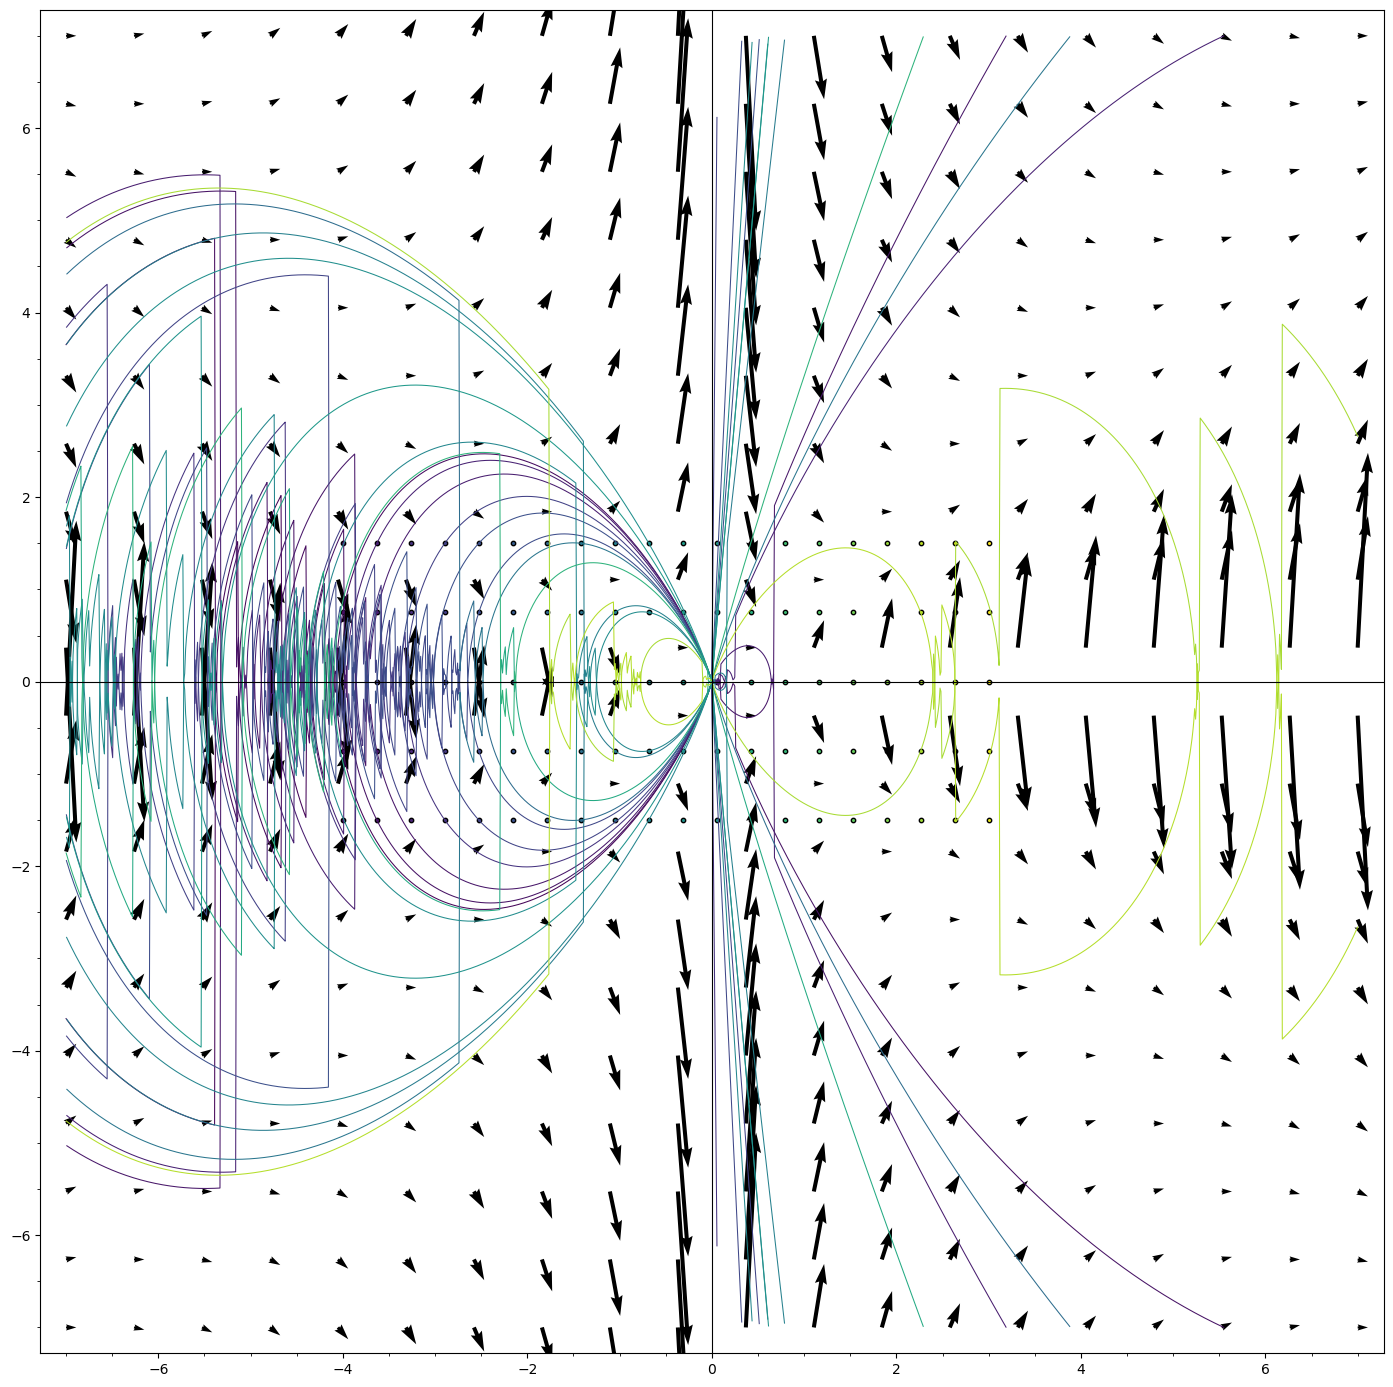

In [146]:
solution_curves = sum(solutions) + ic_points
if vect_or_slope == 'vector' or vect_or_slope == 'vect':
    solution_curves += sage.plot_vector_field(
        (1, f),
        (t, xmin, xmax),
        (y, ymin, ymax),
        figsize=figsize,
        aspect_ratio=aspect_ratio,
    ) 
elif vect_or_slope == 'slope':
    solution_curves += sage.plot_slope_field(
        f,
        (t, xmin, xmax),
        (y, ymin, ymax),
        figsize=figsize,
        aspect_ratio=aspect_ratio,
    )
solution_curves.save("./Plots/2D/solution_curves.svg")
sage.show(solution_curves)